# Preparación datos

In [ ]:
#import sys
#!{sys.executable} -m pip install pandas numpy matplotlib xgboost scikit-learn seaborn

In [1]:
import numpy  as np  
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


**NOTA**: He utilizado Claude como guía para que me explicase aquello que no entendía. 
Me he tomado mi tiempo para entender y explorar mis soluciones. Algunas veces con acierto, otras no.
Cada vez que me trababa, Claude me explicaba el porqué no era buena mi propuesta.
No he podido avanzar hasta entender lo que estaba haciendo y eso me ha consumido mucho tiempo.

## Exploración

In [2]:
ds = pd.read_csv('./airbnb-listings-extract.csv', sep=';')

ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              14780 non-null  int64  
 1   Listing Url                     14780 non-null  str    
 2   Scrape ID                       14780 non-null  int64  
 3   Last Scraped                    14780 non-null  str    
 4   Name                            14779 non-null  str    
 5   Summary                         14189 non-null  str    
 6   Space                           10888 non-null  str    
 7   Description                     14774 non-null  str    
 8   Experiences Offered             14780 non-null  str    
 9   Neighborhood Overview           9134 non-null   str    
 10  Notes                           5644 non-null   str    
 11  Transit                         9066 non-null   str    
 12  Access                          8318 non-nu

In [3]:
print(ds.isnull().any().to_string())

ID                                False
Listing Url                       False
Scrape ID                         False
Last Scraped                      False
Name                               True
Summary                            True
Space                              True
Description                        True
Experiences Offered               False
Neighborhood Overview              True
Notes                              True
Transit                            True
Access                             True
Interaction                        True
House Rules                        True
Thumbnail Url                      True
Medium Url                         True
Picture Url                        True
XL Picture Url                     True
Host ID                           False
Host URL                          False
Host Name                          True
Host Since                         True
Host Location                      True
Host About                         True


# División de datos

Solamente me quedo con las columnas que he seleccionado 

In [4]:
from sklearn.model_selection import train_test_split

cols=['Name', 'Neighbourhood Cleansed', 'City', 'Smart Location', 'Country Code', 'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included', 'Extra People', 'Minimum Nights', 'Maximum Nights', 'Review Scores Rating', 'Review Scores Accuracy', 'Review Scores Cleanliness', 'Review Scores Checkin', 'Review Scores Communication', 'Review Scores Location', 'Review Scores Value', 'Price' ]
ds_full = pd.read_csv("./airbnb-listings-extract.csv", sep=";", usecols=cols)


X_selected_cols = ds_full.drop(columns=['Price'])
y_selected_cols = ds_full['Price']



# Split datos

In [5]:
#split. Ojo! Primero las 'X' y luego las 'y'
X_train, X_test, y_train, y_test = train_test_split(X_selected_cols, y_selected_cols , test_size=0.25, shuffle=True, random_state=0)


No Estratificamos porque estamos en un problema de Regresión

# Limpiar datos


In [6]:
X_train.isnull().any()

Name                            True
Neighbourhood Cleansed         False
City                            True
Smart Location                 False
Country Code                   False
Property Type                  False
Room Type                      False
Accommodates                   False
Bathrooms                       True
Bedrooms                        True
Beds                            True
Guests Included                False
Extra People                   False
Minimum Nights                 False
Maximum Nights                 False
Review Scores Rating            True
Review Scores Accuracy          True
Review Scores Cleanliness       True
Review Scores Checkin           True
Review Scores Communication     True
Review Scores Location          True
Review Scores Value             True
dtype: bool

In [7]:
#pd.isnull(X_train).any()
y_train.info()

<class 'pandas.Series'>
Index: 11085 entries, 14764 to 2732
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
11071 non-null  float64
dtypes: float64(1)
memory usage: 173.2 KB


## Imputación

Imputamos en el dataframe 'X' de train y test

In [8]:
from pandas.api.types import is_numeric_dtype

def impute(train, test):
    '''
    la idea original es mía pero el arreglo (imputar test con la media de train), es de Claude
    '''
    for colname in train.columns:
        if is_numeric_dtype(train[colname].dtype):
            mean = train[colname].mean()
            train[colname] = train[colname].fillna(mean)
            test[colname] = test[colname].fillna(mean, inplace=True)
        else:
            train[colname] = train[colname].fillna(value='Unknown')
            test[colname] = test[colname].fillna(value='Unknown')


impute(X_train, X_test)

'''
Código original:

# Imputamos X_train
for colname in X_train.columns:
    if is_numeric_dtype(X_train[colname].dtype):
        train[colname] = X_train[colname].fillna(X_train[colname].mean())
    if not is_numeric_dtype(X_train[colname].dtype):
        train[colname] = X_train[colname].fillna(value='Unknown')

'''

"\nCódigo original:\n\n# Imputamos X_train\nfor colname in X_train.columns:\n    if is_numeric_dtype(X_train[colname].dtype):\n        X_train[colname].fillna(X_train[colname].mean(), inplace=True)\n    if not is_numeric_dtype(X_train[colname].dtype):\n        X_train[colname].fillna(value='Unknown', inplace=True)\n\n"

Imputamos en el dataframe 'y' de train y test

In [9]:
mean2 = y_train.mean()
y_train.fillna(mean2, inplace=True)
y_test.fillna(mean2, inplace=True)

9612      15.0
4447      25.0
8936      45.0
4006      25.0
13853     40.0
         ...  
309      100.0
785      106.0
14441     55.0
13060     51.0
7049      38.0
Name: Price, Length: 3695, dtype: float64

# Análisis valores nulos

In [10]:
print('Nulls on X_train:', X_train.isnull().sum().sum())
print('Nulls on X_test:', X_test.isnull().sum().sum())

Nulls on X_train: 0
Nulls on X_test: 0


In [11]:
print('Nulls on y_train:', y_train.isnull().sum())
print('Nulls on y_test:', y_test.isnull().sum())

Nulls on y_train: 0
Nulls on y_test: 0


In [12]:
X_train.info() #OK

<class 'pandas.DataFrame'>
Index: 11085 entries, 14764 to 2732
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Name                         11085 non-null  str    
 1   Neighbourhood Cleansed       11085 non-null  str    
 2   City                         11085 non-null  str    
 3   Smart Location               11085 non-null  str    
 4   Country Code                 11085 non-null  str    
 5   Property Type                11085 non-null  str    
 6   Room Type                    11085 non-null  str    
 7   Accommodates                 11085 non-null  int64  
 8   Bathrooms                    11085 non-null  float64
 9   Bedrooms                     11085 non-null  float64
 10  Beds                         11085 non-null  float64
 11  Guests Included              11085 non-null  int64  
 12  Extra People                 11085 non-null  int64  
 13  Minimum Nights               

In [13]:
X_test.isnull().any()

Name                           False
Neighbourhood Cleansed         False
City                           False
Smart Location                 False
Country Code                   False
Property Type                  False
Room Type                      False
Accommodates                   False
Bathrooms                      False
Bedrooms                       False
Beds                           False
Guests Included                False
Extra People                   False
Minimum Nights                 False
Maximum Nights                 False
Review Scores Rating           False
Review Scores Accuracy         False
Review Scores Cleanliness      False
Review Scores Checkin          False
Review Scores Communication    False
Review Scores Location         False
Review Scores Value            False
dtype: bool

In [14]:
print('X_train type:', type(X_train))
print('X_test type:', type(X_test))
print('y_train type:', type(y_train))
print('y_test type:', type(y_test))

X_train type: <class 'pandas.DataFrame'>
X_test type: <class 'pandas.DataFrame'>
y_train type: <class 'pandas.Series'>
y_test type: <class 'pandas.Series'>


In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(11085, 22)
(3695, 22)
(11085,)
(3695,)


# Encoder

In [16]:
print('Unique values')
print('Neighbourhood Cleansed:', X_train['Neighbourhood Cleansed'].nunique())
print('City:', X_train['City'].nunique())
print('Smart Location:', X_train['Smart Location'].nunique())
print('Country Code:', X_train['Country Code'].nunique())
print('Property Type:', X_train['Property Type'].nunique())
print('Room Type:', X_train['Room Type'].nunique())


Unique values
Neighbourhood Cleansed: 431
City: 215
Smart Location: 223
Country Code: 18
Property Type: 21
Room Type: 3


In [17]:
y_test.info()

<class 'pandas.Series'>
Index: 3695 entries, 9612 to 7049
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
3695 non-null   float64
dtypes: float64(1)
memory usage: 57.7 KB


# Análisis de variables 2

Estoy intentando determinar entre `Neighbourhood Cleansed`, `City`, `Smart Location` y `Country Code` para poder descartar las que no sean relevantes. De momento me interesa `Neighbourhood Cleansed` porque es la que más puede influir en el precio. También y según la distribución de los datos, Madrid representa casi el 90%.

In [18]:
#Reemplazamos el kanji por su traducción latina
X_train['Smart Location'] = X_train['Smart Location'].str.replace('马德里', 'Madrid')
X_test['Smart Location'] = X_test['Smart Location'].str.replace('马德里', 'Madrid')

X_train['City'] = X_train['City'].str.replace('马德里', 'Madrid')
X_test['City'] = X_test['City'].str.replace('马德里', 'Madrid')

In [19]:
print(X_train['Smart Location'].value_counts().to_string())


Smart Location
Madrid, Spain                                 9936
Barcelona, Spain                               223
London, United Kingdom                          99
Paris, France                                   80
Palma, Spain                                    39
Roma, Italy                                     31
Alcúdia, Spain                                  31
Berlin, Germany                                 30
Dublin, Ireland                                 25
New York, NY                                    24
Los Angeles, CA                                 23
Wien, Austria                                   20
Brooklyn, NY                                    20
Amsterdam, Netherlands                          16
Rome, Italy                                     15
Toronto, Canada                                 13
Inca, Spain                                     12
Madrid, Comunidad de Madrid, ES, Spain          12
Pollença, Spain                                 10
Palma de Mallorc

In [20]:
print(X_train['Neighbourhood Cleansed'].value_counts().to_string())

Neighbourhood Cleansed
Embajadores                                                                       1385
Universidad                                                                        994
Palacio                                                                            834
Sol                                                                                722
Justicia                                                                           605
Cortes                                                                             572
Trafalgar                                                                          246
Argüelles                                                                          206
Palos de Moguer                                                                    195
Goya                                                                               175
Puerta del Angel                                                                   150
Recoletos           

`Smart Location` = `City`+`Country`

In [21]:
X_train['Smart Location'].value_counts()

#X_train[X_train['Smart Location'] == '马德里, Spain']

Smart Location
Madrid, Spain               9936
Barcelona, Spain             223
London, United Kingdom        99
Paris, France                 80
Palma, Spain                  39
                            ... 
Hong Kong                      1
San Fernando, CA               1
Tsim Sha Tsui, Hong Kong       1
Beverly Hills, CA              1
Aravaca (Madrid), Spain        1
Name: count, Length: 222, dtype: int64

Magnitud del "desastre". Columna `Price` antes (train y test)

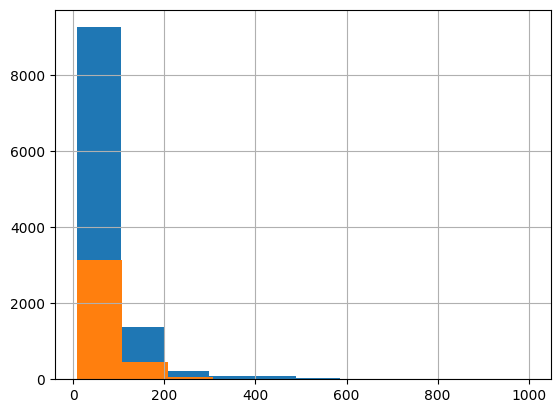

In [22]:
_ = y_train.hist()
_ = y_test.hist()

# Encoding

In [23]:
#Encode para las columnas de tipo object
#Codigo: sklearn
#Consejos y ayuda: Claude

from sklearn.preprocessing import TargetEncoder

encoder = TargetEncoder()
encoder.fit(X_train[['Neighbourhood Cleansed', 'Country Code', 'Property Type', 'Room Type']], y_train)
X_train[['Neighbourhood Cleansed', 'Country Code', 'Property Type', 'Room Type']] = encoder.transform(X_train[['Neighbourhood Cleansed', 'Country Code', 'Property Type', 'Room Type']])
X_test[['Neighbourhood Cleansed', 'Country Code', 'Property Type', 'Room Type']] = encoder.transform(X_test[['Neighbourhood Cleansed', 'Country Code', 'Property Type', 'Room Type']])

## ¿Por qué elegí `TargetEncoder`?

Primero solucioné una duda que me llevaba de un lado a otro. Resulta que finalmente me enteré que
convertir datos categóricos (texto) a números se llamaba de diferente forma en R (factor), Pandas (Category) y sklearn (Encoder). Luego entendí la importancia: los _estimadores_ solamente trabajan con datos numéricos!


Buscando entre los estimadores de sklearn (más los diálogos orientativos con Claude) tenía como opciones 
las siguientes:

* `OrdinalEncoder` era asignar un valor ordinal (1,2,3 ...) a los valores dependiendo de su posición. 

* `OneHotEncoder` parecía una buena opción pero el hecho de tener variables con alta cardinalidad 
                como `Neighbourhood Cleansed`con 431 valores únicos no parecía una buena opción.

* `LabelEncoder` etiqueta las clases desde 1 a n_clases - 1. No reflejaba el peso.

* `TargetEncoder` finalmente leí lo siguiente en la documentación de sklearn:

>  Each category is encoded based on a shrunk estimate of the average target values for observations belonging to the category. The encoding scheme mixes the global target mean with the target mean conditioned on the value of the category 

es decir, la codificación se realiza en base una estimación reducida del promedio para las observaciones de cada categoría. Fue esta última opción la que he elegido para realizar la codificación (Encoding) por asignar un valor más correspondiente al "peso" del dato en su conjunto.

In [24]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 11085 entries, 14764 to 2732
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Name                         11085 non-null  str    
 1   Neighbourhood Cleansed       11085 non-null  float64
 2   City                         11085 non-null  str    
 3   Smart Location               11085 non-null  str    
 4   Country Code                 11085 non-null  float64
 5   Property Type                11085 non-null  float64
 6   Room Type                    11085 non-null  float64
 7   Accommodates                 11085 non-null  int64  
 8   Bathrooms                    11085 non-null  float64
 9   Bedrooms                     11085 non-null  float64
 10  Beds                         11085 non-null  float64
 11  Guests Included              11085 non-null  int64  
 12  Extra People                 11085 non-null  int64  
 13  Minimum Nights               

Quito las columnas `City` y `Smart Location` porque creo que son redundantes y 
no aportan a determinar el precio. Si que considero importante `Neighbourhood Cleansed`por ser granular.
También quito `Name`por no ser necesaria para la estimación.

In [25]:
X_train = X_train.drop(columns=['Name', 'City', 'Smart Location'])

In [26]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 11085 entries, 14764 to 2732
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Neighbourhood Cleansed       11085 non-null  float64
 1   Country Code                 11085 non-null  float64
 2   Property Type                11085 non-null  float64
 3   Room Type                    11085 non-null  float64
 4   Accommodates                 11085 non-null  int64  
 5   Bathrooms                    11085 non-null  float64
 6   Bedrooms                     11085 non-null  float64
 7   Beds                         11085 non-null  float64
 8   Guests Included              11085 non-null  int64  
 9   Extra People                 11085 non-null  int64  
 10  Minimum Nights               11085 non-null  int64  
 11  Maximum Nights               11085 non-null  int64  
 12  Review Scores Rating         11085 non-null  float64
 13  Review Scores Accuracy       

In [27]:
# Quitamos en test
X_test = X_test.drop(columns=['Name', 'City', 'Smart Location'])

In [28]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 3695 entries, 9612 to 7049
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Neighbourhood Cleansed       3695 non-null   float64
 1   Country Code                 3695 non-null   float64
 2   Property Type                3695 non-null   float64
 3   Room Type                    3695 non-null   float64
 4   Accommodates                 3695 non-null   int64  
 5   Bathrooms                    3695 non-null   float64
 6   Bedrooms                     3695 non-null   float64
 7   Beds                         3695 non-null   float64
 8   Guests Included              3695 non-null   int64  
 9   Extra People                 3695 non-null   int64  
 10  Minimum Nights               3695 non-null   int64  
 11  Maximum Nights               3695 non-null   int64  
 12  Review Scores Rating         3695 non-null   float64
 13  Review Scores Accuracy       36

# Correlación

Una vez limpios los datos y determinados en gran medida las columnas a utilizar 
vamos a ver qué campos de los seleccionados pueden estar duplicados.

In [29]:
X_train.corr()

,Neighbourhood Cleansed,Country Code,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Guests Included,Extra People,Minimum Nights,Maximum Nights,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value
Neighbourhood Cleansed,1.000000,0.328089,0.142246,0.215843,0.264277,0.241677,0.217142,0.214272,0.117195,0.104890,0.016938,0.004505,0.025012,0.023610,0.028303,-0.008387,-0.006583,0.162715,0.010894
Country Code,0.328089,1.000000,0.049612,-0.009129,-0.025418,-0.030026,-0.021995,-0.041347,-0.020048,0.105931,0.000911,-0.006152,0.035060,0.026333,0.011624,0.031346,0.029850,0.013615,0.034271
Property Type,0.142246,0.049612,1.000000,0.069092,0.133092,0.155123,0.178237,0.136881,0.072456,-0.007616,0.018283,0.005307,0.003243,0.005094,0.004004,-0.002273,0.000931,-0.022596,0.001676
Room Type,0.215843,-0.009129,0.069092,1.000000,0.523693,0.024077,0.270444,0.319795,0.338946,0.104287,0.028606,0.007659,-0.019567,0.013323,0.025957,-0.010573,0.010654,0.066151,-0.030944
Accommodates,0.264277,-0.025418,0.133092,0.523693,1.000000,0.427799,0.722264,0.835977,0.559464,0.244384,0.006665,0.001056,-0.043083,-0.041666,-0.012427,-0.063379,-0.048219,0.009195,-0.051701
Bathrooms,0.241677,-0.030026,0.155123,0.024077,0.427799,1.000000,0.518356,0.473737,0.233280,0.086331,0.029504,-0.003369,0.006916,0.002933,0.005576,-0.038139,-0.037276,0.001523,-0.004555
Bedrooms,0.217142,-0.021995,0.178237,0.270444,0.722264,0.518356,1.000000,0.727054,0.429750,0.131463,0.020507,0.000013,0.011067,0.002191,0.010393,-0.025573,-0.010584,-0.027859,-0.008999
Beds,0.214272,-0.041347,0.136881,0.319795,0.835977,0.473737,0.727054,1.000000,0.450983,0.178590,0.007017,0.001007,-0.031095,-0.041637,-0.008446,-0.047264,-0.033820,-0.021720,-0.037405
Guests Included,0.117195,-0.020048,0.072456,0.338946,0.559464,0.233280,0.429750,0.450983,1.000000,0.349619,0.003392,-0.004878,0.010615,0.014917,0.029070,0.001533,0.006127,0.040984,0.005200
Extra People,0.104890,0.105931,-0.007616,0.104287,0.244384,0.086331,0.131463,0.178590,0.349619,1.000000,-0.019362,-0.003389,0.020516,0.011427,0.037673,0.019311,0.013445,0.040760,0.010704


In [30]:
import sys
!{sys.executable} -m pip install seaborn



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


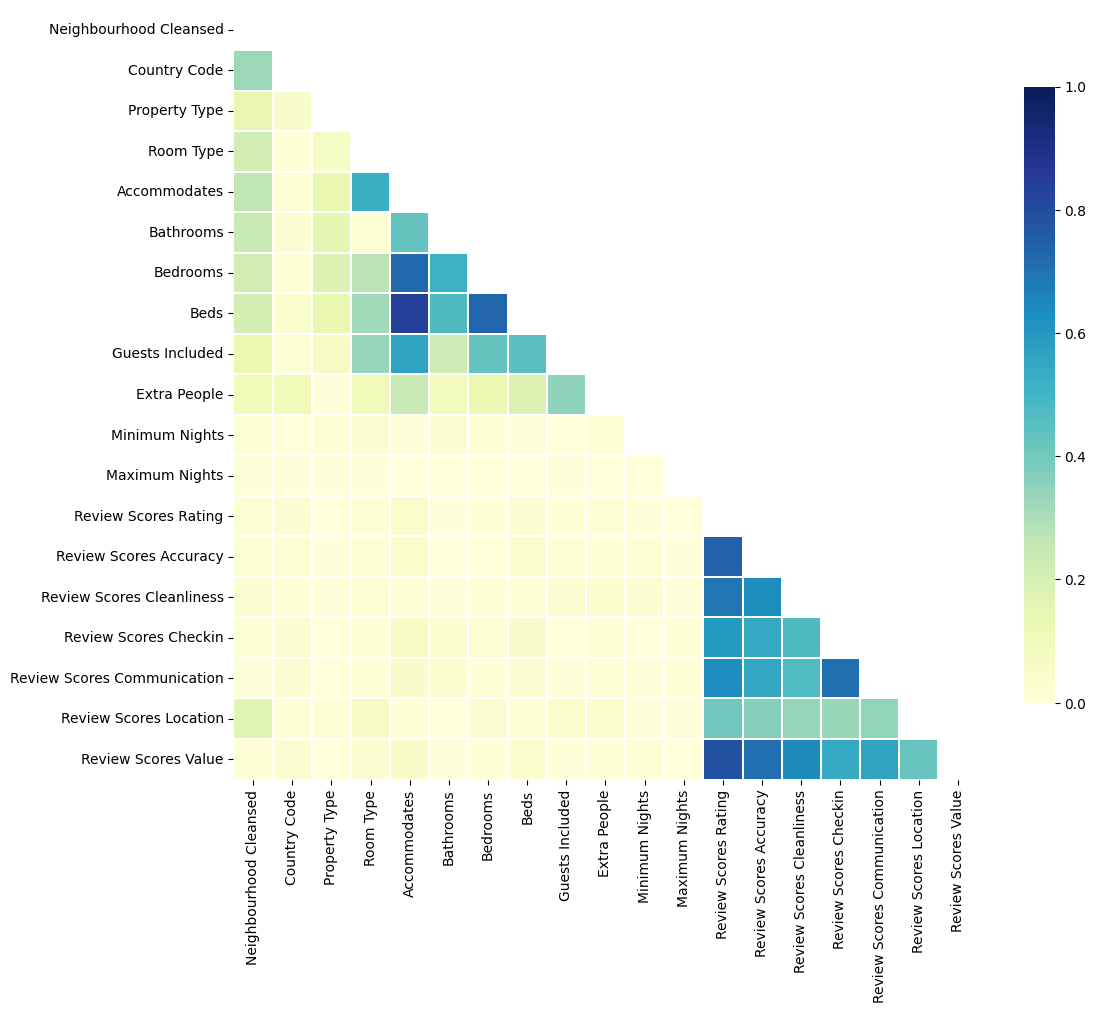

In [31]:
import seaborn as sns
# Compute the correlation matrix
corr = np.abs(X_train.corr())

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()

En la matriz de correlación anterior identifico las variables redundantes que puedo eliminar.
Para `Review Scores Rating` el resto de las 'Review Scores' podemos eliminarlas.
Para `Accommodates`y `Bedroom`, podemos eliminar `Beds`

In [32]:
X_train = X_train.drop(columns=['Beds', 'Review Scores Accuracy', 'Review Scores Cleanliness', 'Review Scores Checkin', 'Review Scores Communication', 'Review Scores Location', 'Review Scores Value'])

In [33]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 11085 entries, 14764 to 2732
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Neighbourhood Cleansed  11085 non-null  float64
 1   Country Code            11085 non-null  float64
 2   Property Type           11085 non-null  float64
 3   Room Type               11085 non-null  float64
 4   Accommodates            11085 non-null  int64  
 5   Bathrooms               11085 non-null  float64
 6   Bedrooms                11085 non-null  float64
 7   Guests Included         11085 non-null  int64  
 8   Extra People            11085 non-null  int64  
 9   Minimum Nights          11085 non-null  int64  
 10  Maximum Nights          11085 non-null  int64  
 11  Review Scores Rating    11085 non-null  float64
dtypes: float64(7), int64(5)
memory usage: 1.1 MB


In [34]:
# Quitamos las columnas en test
X_test = X_test.drop(columns=['Beds', 'Review Scores Accuracy', 'Review Scores Cleanliness', 'Review Scores Checkin', 'Review Scores Communication', 'Review Scores Location', 'Review Scores Value'])

In [35]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 3695 entries, 9612 to 7049
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Neighbourhood Cleansed  3695 non-null   float64
 1   Country Code            3695 non-null   float64
 2   Property Type           3695 non-null   float64
 3   Room Type               3695 non-null   float64
 4   Accommodates            3695 non-null   int64  
 5   Bathrooms               3695 non-null   float64
 6   Bedrooms                3695 non-null   float64
 7   Guests Included         3695 non-null   int64  
 8   Extra People            3695 non-null   int64  
 9   Minimum Nights          3695 non-null   int64  
 10  Maximum Nights          3695 non-null   int64  
 11  Review Scores Rating    3695 non-null   float64
dtypes: float64(7), int64(5)
memory usage: 375.3 KB


In [36]:
# Gráficos

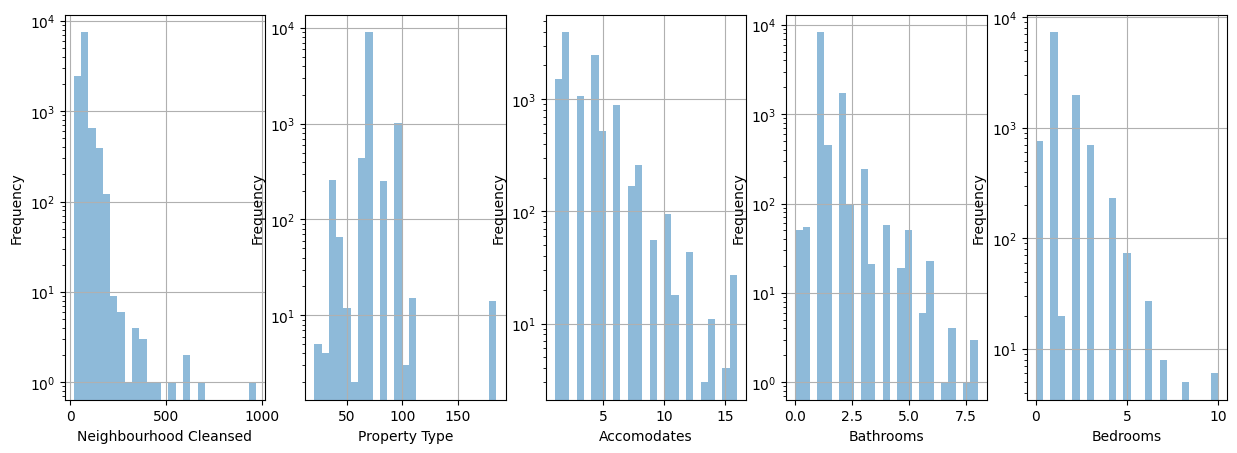

In [37]:
plt.figure(figsize=(15, 5))

plt.subplot(1,5,1)

X_train['Neighbourhood Cleansed'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.yscale("log")
plt.xlabel('Neighbourhood Cleansed')

plt.subplot(1,5,2)
X_train['Property Type'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.yscale("log")
plt.xlabel('Property Type')

plt.subplot(1,5,3)
X_train['Accommodates'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.yscale("log")
plt.xlabel('Accomodates')

plt.subplot(1,5,4)
X_train['Bathrooms'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.yscale("log")
plt.xlabel('Bathrooms')

plt.subplot(1,5,5)
X_train['Bedrooms'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.yscale("log")
plt.xlabel('Bedrooms')

plt.show()

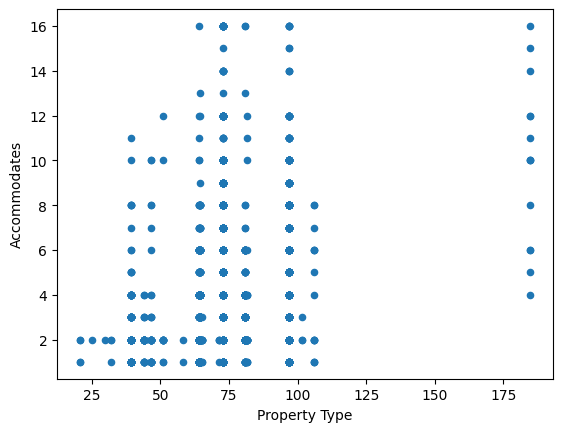

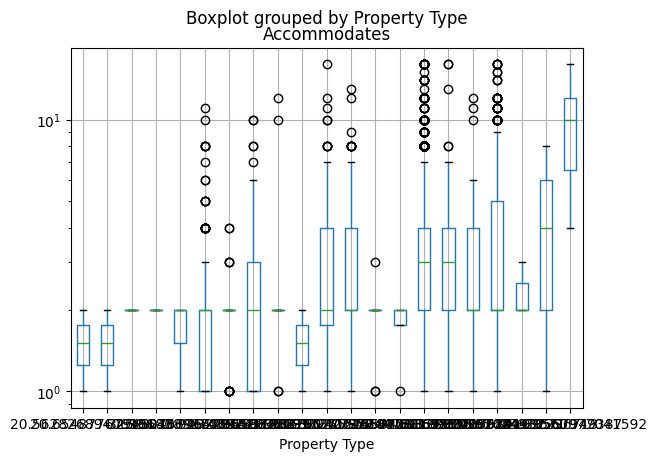

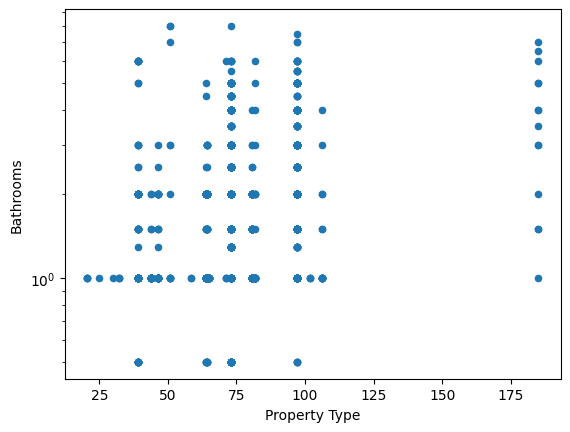

In [38]:
X_train.plot(kind = 'scatter',x='Property Type',y = 'Accommodates')
#plt.yscale("log")
plt.xlabel('Property Type')
plt.ylabel('Accommodates')
plt.show()

X_train.boxplot(by='Property Type',column = 'Accommodates')
plt.yscale("log")
plt.show()

X_train.plot(kind = 'scatter',x='Property Type',y = 'Bathrooms')
plt.yscale("log")
plt.xlabel('Property Type')
plt.ylabel('Bathrooms')
plt.show()

# Procesado

In [39]:
# A causa del Encoding de las variables (conversión a numérico) han quedado valores 
# y de un posterior escalado, las variables contienen valores NaN
# En esta parte, después del Encoding y antes del Scale, limpiamos las variables
impute(X_train, X_test)

## Lasso

In [ ]:
from sklearn.linear_model import Lasso


# Utilizo el Scaler porque es importante para modelos lineales como Ridge y Lasso
# Con esto evitamos que una columna con valores 0 a 10 tenga una consideración diferente 
# que otra columna con valores de 100.000 a 1.000.000
# No tiene afectación en los algoritmos de árboles

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

best mean cross-validation score: -52.866
best parameters: {'alpha': np.float64(0.4216965034285822)}


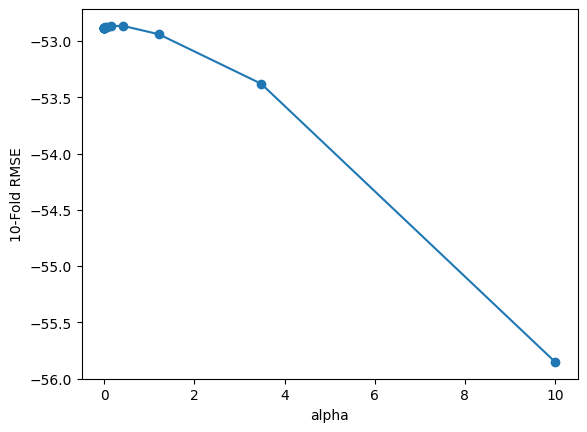

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


alpha_vector = np.logspace(-10,1,25)
param_grid_def = {'alpha': alpha_vector }

grid_ls = GridSearchCV(Lasso(), 
                    scoring='neg_root_mean_squared_error',
                    param_grid=param_grid_def, 
                    cv=10)
grid_ls.fit(X_train_scaled, y_train)
print("best mean cross-validation score: {:.3f}".format(grid_ls.best_score_))
print("best parameters: {}".format(grid_ls.best_params_))

scores = np.array(grid_ls.cv_results_['mean_test_score'])
#plt.plot(maxDepth,scores,'-o')
plt.plot(alpha_vector, scores, '-o')
#plt.xlabel('max_depth',fontsize=16)
plt.xlabel('alpha')
plt.ylabel('10-Fold RMSE')
#plt.ylim((-1, 0))
plt.show()

In [51]:
print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaNs in X_train:", np.isnan(X_train.values).sum())
print("NaNs in X_test:", np.isnan(X_test.values).sum())


NaNs in X_train_scaled: 0
NaNs in X_train: 0
NaNs in X_test: 0


In [52]:
y_train.isnull().value_counts()


Price
False    11085
Name: count, dtype: int64

## Decision tree

Nota: Al ser un algoritmo de arbol, no he escalado los datos.

best mean cross-validation score: -51.005
best parameters: {'max_depth': 7}


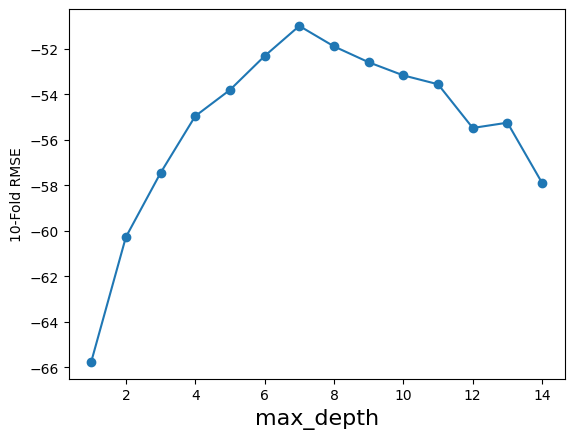

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

maxDepth = range(1,15)
param_grid_def = {'max_depth': maxDepth }

grid_dt = GridSearchCV(DecisionTreeRegressor(), 
                    scoring='neg_root_mean_squared_error',
                    param_grid=param_grid_def, 
                    cv=10)
grid_dt.fit(X_train_scaled, y_train)
print("best mean cross-validation score: {:.3f}".format(grid_dt.best_score_))
print("best parameters: {}".format(grid_dt.best_params_))

scores = np.array(grid_dt.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth',fontsize=16)
plt.ylabel('10-Fold RMSE')
#plt.ylim((-1, 0))
plt.show()

In [44]:
# XGBoost

Fitting 10 folds for each of 14 candidates, totalling 140 fits
[CV] END ........................................max_depth=1; total time=   0.1s
[CV] END ........................................max_depth=1; total time=   0.2s
[CV] END ........................................max_depth=1; total time=   0.1s
[CV] END ........................................max_depth=1; total time=   0.1s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.1s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END .....................................

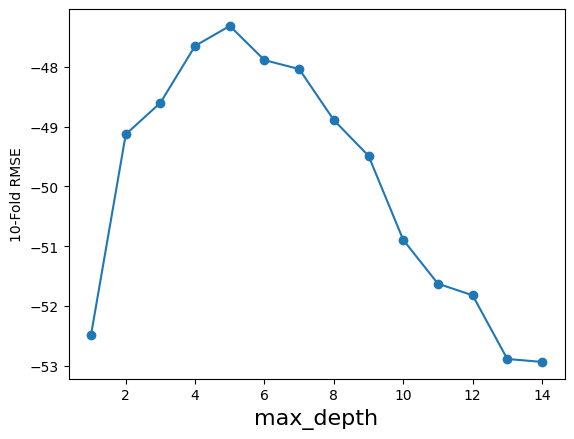

In [54]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

maxDepth = range(1,15)
param_grid_def = {'max_depth': maxDepth }

grid_xgb = GridSearchCV(XGBRegressor(), 
                    scoring='neg_root_mean_squared_error',
                    param_grid=param_grid_def, 
                    cv=10,
                    verbose=2)
grid_xgb.fit(X_train_scaled, y_train)
print("best mean cross-validation score: {:.3f}".format(grid_xgb.best_score_))
print("best parameters: {}".format(grid_xgb.best_params_))

scores = np.array(grid_xgb.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth',fontsize=16)
plt.ylabel('10-Fold RMSE')
#plt.ylim((-1, 0))
plt.show()

# Scoring

In [57]:
from sklearn.metrics import mean_squared_error

y_pred_ls = grid_ls.predict(X_test_scaled)
y_pred_dt = grid_dt.predict(X_test_scaled)
y_pred_xgb = grid_xgb.predict(X_test_scaled)

print('RMSE Lasso        :', np.sqrt(mean_squared_error(y_test, y_pred_ls)))
print('RMSE Decision Tree:', np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print('RMSE XGBoost      :', np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

RMSE Lasso        : 54.07468561510077
RMSE Decision Tree: 52.471614867051215
RMSE XGBoost      : 45.78209980528494


El algoritmo XGBoost es el que tiene mejor rendimiento a la hora de predecir 
ya que generaliza mejor el precio medio que los otros dos algoritmos puesto que el resultado
en la cv y en X_test es menor (47.32 contra 45.78).